In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

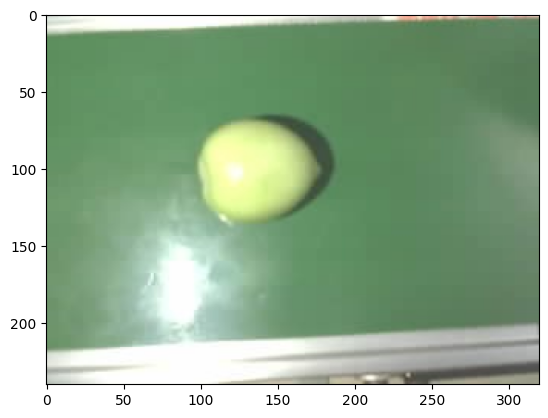

In [5]:
path = '../dataset/Dataset_Cachua/test/Unripe/20260411112715.jpg'

img = cv2.imread(path)
img_raw = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_raw)


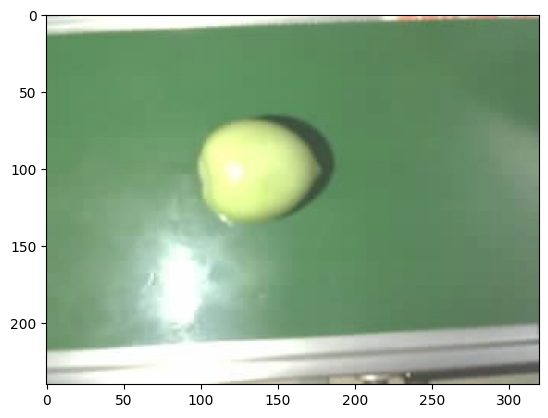

In [7]:
hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
plt.imshow(hsv_display)
plt.show()

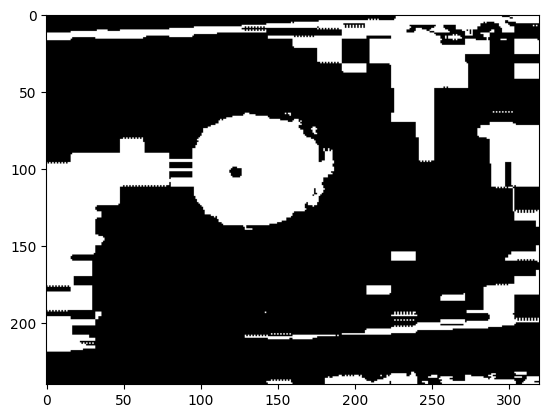

In [15]:
lower_red = np.array([0, 30, 50])
upper_red = np.array([30, 255, 255])
lower_red_wrap = np.array([160, 30, 50])
upper_red_wrap = np.array([180, 255, 255])
lower_green = np.array([30, 30, 50])
upper_green = np.array([60, 255, 255])
    
mask = cv2.inRange(hsv, lower_red, upper_red)
mask |= cv2.inRange(hsv, lower_red_wrap, upper_red_wrap)
mask |= cv2.inRange(hsv, lower_green, upper_green)

plt.imshow(mask, cmap='gray')

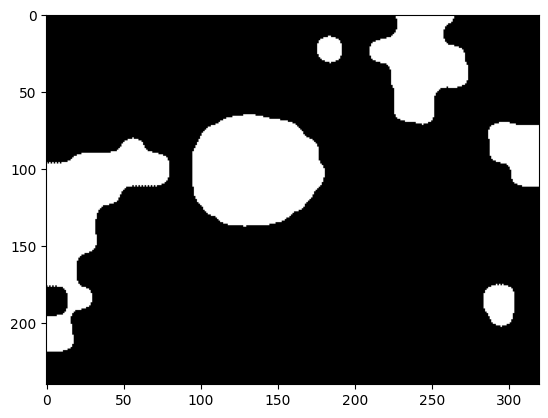

In [17]:
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small)
    
kernel_medium = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_medium)

plt.imshow(kernel_small)
plt.imshow(mask, cmap='gray')

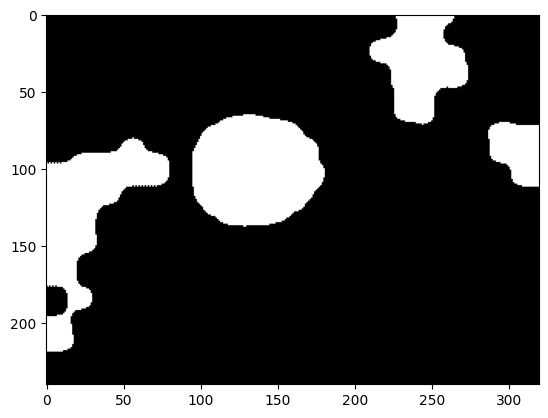

In [20]:
contours_temp, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
solid_mask = np.zeros_like(mask)
if contours_temp:
        for cnt in contours_temp:
            if cv2.contourArea(cnt) > 500:
                cv2.drawContours(solid_mask, [cnt], -1, 255, thickness=cv2.FILLED)
mask = solid_mask

plt.imshow(mask, cmap='gray')

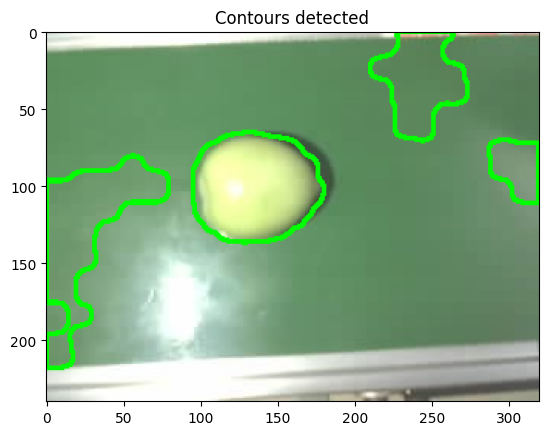

In [21]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0,255,0), 2)
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title("Contours detected")
plt.show()


In [24]:
img_size = 299

In [25]:
    if not contours:
        img = cv2.resize(img, (img_size, img_size))
        
    H, W = img.shape[:2]
    center_x, center_y = W // 2, H // 2  # Tọa độ tâm của bức ảnh
    
    best_cnt = None
    min_dist = float('inf')
    
    for cnt in contours:
        # Bỏ qua các hạt bụi hoặc nhiễu quá nhỏ
        if cv2.contourArea(cnt) < 1000:
            continue
            
        # Tính Trọng tâm (Centroid) của khối màu bằng cv2.moments
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0
            
        # Tính khoảng cách từ Trọng tâm vật thể tới Tâm bức ảnh
        dist = (cx - center_x)**2 + (cy - center_y)**2
        
        # Chọn vật thể CÓ KHOẢNG CÁCH GẦN TÂM NHẤT
        if dist < min_dist:
            min_dist = dist
            best_cnt = cnt
            
    # Nếu lọc xong không còn gì, trả về ảnh gốc
    if best_cnt is None:
        img = cv2.resize(img, (img_size, img_size))

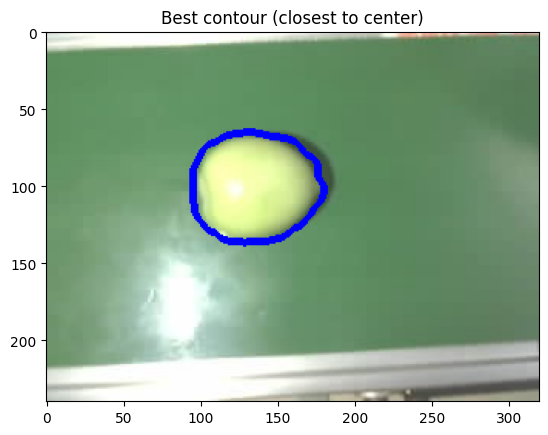

In [26]:
img_best = img.copy()
cv2.drawContours(img_best, [best_cnt], -1, (255,0,0), 3)
plt.imshow(cv2.cvtColor(img_best, cv2.COLOR_BGR2RGB))
plt.title("Best contour (closest to center)")
plt.show()


In [27]:
image = img

In [28]:
    x, y, w, h = cv2.boundingRect(best_cnt)
    x, y = max(0, x), max(0, y)
    w, h = min(W - x, w), min(H - y, h)
    
    cropped_roi = image[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]
    
    roi_bg_removed = cv2.bitwise_and(cropped_roi, cropped_roi, mask=cropped_mask)
    
    h_crop, w_crop = roi_bg_removed.shape[:2]
    max_side = max(h_crop, w_crop)
    
    top = (max_side - h_crop) // 2
    bottom = max_side - h_crop - top
    left = (max_side - w_crop) // 2
    right = max_side - w_crop - left
    
    squared_img = cv2.copyMakeBorder(
        roi_bg_removed, top, bottom, left, right, 
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    
    img_clean = cv2.resize(squared_img, (img_size, img_size))

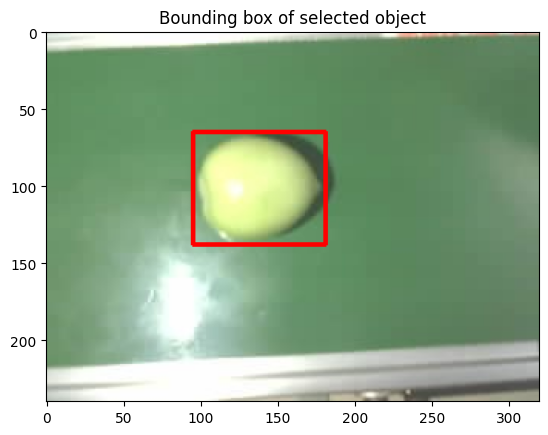

In [29]:
img_bbox = img.copy()
x, y, w, h = cv2.boundingRect(best_cnt)
cv2.rectangle(img_bbox, (x,y), (x+w, y+h), (0,0,255), 2)
plt.imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB))
plt.title("Bounding box of selected object")
plt.show()


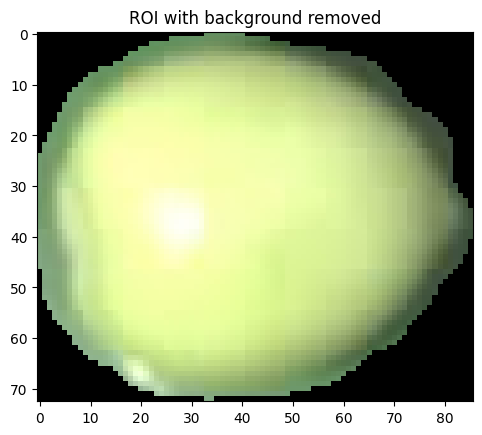

In [30]:
plt.imshow(cv2.cvtColor(roi_bg_removed, cv2.COLOR_BGR2RGB))
plt.title("ROI with background removed")
plt.show()


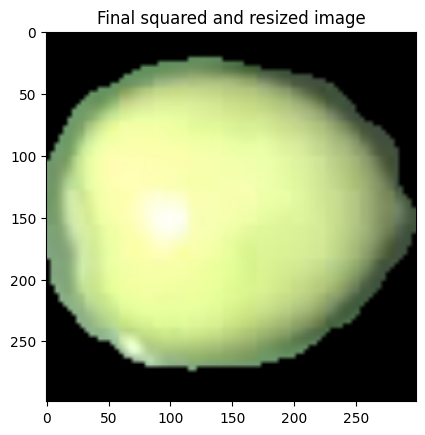

In [31]:
final_img = cv2.resize(squared_img, (img_size, img_size))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Final squared and resized image")
plt.show()
